In [ ]:
import torch
import torchvision.transforms as T
from torchvision.models.vgg import vgg16_bn
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Importer ZennitCRP
from zennit.composites import EpsilonPlusFlat
from zennit.canonizers import SequentialMergeBatchNorm
from crp.attribution import CondAttribution
from crp.helper import get_layer_names
from crp.concepts import ChannelConcept

In [1]:
import torch
from torchvision.models.vgg import vgg16_bn
import torchvision.transforms as T
from PIL import Image

device = "cuda:0" if torch.cuda.is_available() else "cpu"

model = vgg16_bn(True).to(device)
model.eval()

transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

/home/timotheewsl/PER/Guillaume/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(
/home/timotheewsl/PER/Guillaume/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_BN_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_BN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [2]:
image_path = "data2/lizard.jpg"
#image_path = "data/n01843383_180.jpeg"

In [3]:
#image = Image.open(image_path)
image = Image.open(image_path).convert("RGB")
input_tensor = transform(image).unsqueeze(0).to(device)

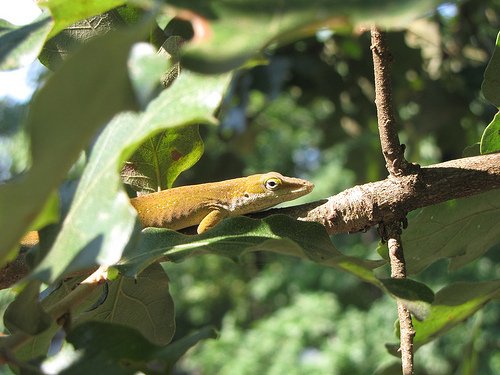

In [4]:
image

In [5]:
output = model(input_tensor)
pred_class = torch.argmax(output, dim=1).item()
print(f"Classe prédite: {pred_class}")
probs = torch.nn.functional.softmax(output, dim=1)
print(f"Probabilités: {probs[0, pred_class]}")

Classe prédite: 40
Probabilités: 0.7104917168617249


/home/timotheewsl/PER/Guillaume/.venv/lib/python3.10/site-packages/torch/autograd/graph.py:824: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:181.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


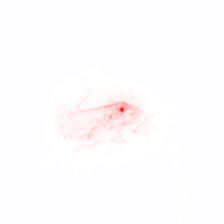

In [6]:
from zennit.composites import EpsilonPlusFlat
from zennit.canonizers import SequentialMergeBatchNorm
from crp.attribution import CondAttribution
from crp.helper import get_layer_names
from crp.image import imgify

composite = EpsilonPlusFlat([SequentialMergeBatchNorm()])
attribution = CondAttribution(model, no_param_grad=True)

input_tensor.requires_grad = True

conditions = [{"y": [pred_class], "features.40": [469]}]
heatmap, _, _, _ = attribution(input_tensor, conditions, composite)

imgify(heatmap, symmetric=True)

In [7]:
activations = {}

def hook_fn(module, input, output, idx):
    activations[idx] = output.detach()

# Ajouter des hooks à toutes les couches convolutives
hooks = []
for idx, layer in enumerate(model.features):
    if isinstance(layer, torch.nn.Conv2d):
        hook = layer.register_forward_hook(lambda module, input, output, idx=idx: hook_fn(module, input, output, idx))
        hooks.append(hook)

# Passer une image dans le modèle
dummy_input = torch.randn(1, 3, 224, 224).to(device)  # Une image factice
_ = model(dummy_input)

# Désenregistrer les hooks
for hook in hooks:
    hook.remove()

# Vérifier les activations disponibles
print(f"Activations enregistrées : {activations.keys()}")


Activations enregistrées : dict_keys([0, 3, 7, 10, 14, 17, 20, 24, 27, 30, 34, 37, 40])


In [8]:
def zero_out_feature(module, input, output):
    output[:, 89, :, :] = 0  # Désactiver la feature 89
    return output

# Ajouter le hook
hook = model.features[40].register_forward_hook(zero_out_feature)

# Faire une prédiction avec la feature désactivée
output_disabled = model(input_tensor)
probs_disabled = torch.nn.functional.softmax(output_disabled, dim=1)

# Supprimer le hook
hook.remove()

# Comparer avec la prédiction originale
output_original = model(input_tensor)
probs_original = torch.nn.functional.softmax(output_original, dim=1)

# Calcul de l'importance
importance = probs_original[0, pred_class] - probs_disabled[0, pred_class]
print(f"Importance de la feature 89: {importance:.4f}")


Importance de la feature 89: -0.0014


In [9]:
import torch
from torchvision.models.vgg import vgg16_bn

def compute_feature_importance(model, input_tensor, layer_idx, num_features, pred_class):
    """
    Calcule l'importance de chaque feature d'une couche donnée pour une classe prédite.

    Arguments :
    - model : le modèle VGG16
    - input_tensor : l'image d'entrée sous forme de tenseur
    - layer_idx : l'index de la couche (ex : 40)
    - num_features : le nombre total de features dans cette couche (ex : 512)
    - pred_class : la classe prédite initialement

    Retourne :
    - Un dictionnaire {feature_idx : importance} trié par importance décroissante
    """

    # Obtenir la probabilité originale de la classe prédite
    with torch.no_grad():
        output_original = model(input_tensor)
        probs_original = torch.nn.functional.softmax(output_original, dim=1)
        original_score = probs_original[0, pred_class].item()

    feature_importance = {}

    # Désactiver chaque feature une par une et mesurer l'impact
    for feature_idx in range(num_features):
        def zero_out_feature(module, input, output, feature_idx=feature_idx):
            output[:, feature_idx, :, :] = 0  # Désactiver la feature
            return output

        # Ajouter un hook temporaire
        hook = model.features[layer_idx].register_forward_hook(zero_out_feature)

        # Faire une prédiction avec la feature désactivée
        with torch.no_grad():
            output_disabled = model(input_tensor)
            probs_disabled = torch.nn.functional.softmax(output_disabled, dim=1)
            new_score = probs_disabled[0, pred_class].item()

        # Supprimer le hook
        hook.remove()

        # Calcul de l'importance
        importance = original_score - new_score
        feature_importance[feature_idx] = importance

        # Affichage de progression
        print(f"Feature {feature_idx+1}/{num_features} - Importance: {importance:.4f}")

    # Trier les features par importance décroissante
    sorted_importance = dict(sorted(feature_importance.items(), key=lambda item: item[1], reverse=True))

    return sorted_importance


In [10]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Assurez-vous que le dossier de sortie existe
output_folder = "output_images"
os.makedirs(output_folder, exist_ok=True)

input_tensor.requires_grad = True
batch = 8
num_features = 8
features_per_row = 8  # 8 images par ligne
num_feature_per_batch = int(num_features / batch)
all_conditions = []
all_heatmaps = []

for i in range(batch):
    # Initialisation des conditions et de l'attribution
    conditions = [{"y": [40], "features.40": [j]} for j in range(i*num_feature_per_batch, (i+1)*num_feature_per_batch)]
    all_conditions.append(conditions)
    heatmaps, _, _, _ = attribution(input_tensor, conditions, composite)
    all_heatmaps.append(heatmaps)

# Concaténer les heatmaps
heatmaps = np.concatenate(all_heatmaps, axis=0)

# Sauvegarde de chaque heatmap individuellement
for idx, heatmap in enumerate(heatmaps):
    save_path = os.path.join(output_folder, f"{idx+1}.jpeg")
    plt.imsave(save_path, heatmap, cmap="hot")  # Utilisation du colormap "hot" pour les heatmaps
    print(f"Image sauvegardée : {save_path}")
imgify(heatmaps, symmetric=True, grid=(num_features // features_per_row, features_per_row))


TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Assurez-vous que le dossier de sortie existe
output_folder = "output_images2"
os.makedirs(output_folder, exist_ok=True)

input_tensor.requires_grad = True
batch = 8
num_features = 8
features_per_row = 8  # 8 images par ligne
num_feature_per_batch = int(num_features / batch)
all_conditions = []
all_heatmaps = []

for i in range(batch):
    # Initialisation des conditions et de l'attribution
    conditions = [{"y": [40], "features.40": [j]} for j in range(i*num_feature_per_batch, (i+1)*num_feature_per_batch)]
    all_conditions.append(conditions)
    heatmaps, _, _, _ = attribution(input_tensor, conditions, composite)
    all_heatmaps.append(heatmaps)

# Concaténer les heatmaps
heatmaps = np.concatenate(all_heatmaps, axis=0)

# Normalisation globale sur toutes les heatmaps
vmin = heatmaps.min()  # Valeur minimale globale
vmax = heatmaps.max()  # Valeur maximale globale

# Sauvegarde de chaque heatmap individuellement avec une échelle de couleur cohérente
for idx, heatmap in enumerate(heatmaps):
    save_path = os.path.join(output_folder, f"{idx+1}.jpeg")
    plt.imsave(save_path, heatmap, cmap="hot", vmin=vmin, vmax=vmax)
    print(f"Image sauvegardée : {save_path}")

# Affichage avec imgify en conservant les mêmes couleurs
imgify(heatmaps, symmetric=True, grid=(num_features // features_per_row, features_per_row))


In [ ]:
print(f"Min value for a pixel: {vmin}, Max value for a pixel: {vmax}")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Assurez-vous que le dossier de sortie existe
output_folder = "output_images3"
os.makedirs(output_folder, exist_ok=True)

input_tensor.requires_grad = True
batch = 8
num_features = 8
features_per_row = 8  # 8 images par ligne
num_feature_per_batch = int(num_features / batch)
all_conditions = []
all_heatmaps = []

for i in range(batch):
    # Initialisation des conditions et de l'attribution
    conditions = [{"y": [40], "features.40": [j]} for j in range(i*num_feature_per_batch, (i+1)*num_feature_per_batch)]
    all_conditions.append(conditions)
    heatmaps, _, _, _ = attribution(input_tensor, conditions, composite)
    all_heatmaps.append(heatmaps)

# Concaténer les heatmaps
heatmaps = np.concatenate(all_heatmaps, axis=0)

# Normalisation globale sur toutes les heatmaps
vmax = max(abs(heatmaps.min()), abs(heatmaps.max()))  # Prend la plus grande valeur absolue
vmin = -vmax  # Rend l'échelle symétrique

# Sauvegarde de chaque heatmap individuellement avec colorbar
for idx, heatmap in enumerate(heatmaps):
    fig, ax = plt.subplots(figsize=(4, 4))  # Taille ajustable si besoin
    cax = ax.imshow(heatmap, cmap="seismic", vmin=vmin, vmax=vmax)

    # Ajouter la colorbar à droite
    cbar = fig.colorbar(cax, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Activation Score")  # Légende de la colorbar

    # Enregistrer l'image avec la légende
    save_path = os.path.join(output_folder, f"{idx+1}.jpeg")
    plt.savefig(save_path, bbox_inches='tight')  # Sauvegarde propre sans bordures inutiles
    plt.close(fig)  # Fermer la figure pour éviter d'accumuler en mémoire

    print(f"Image sauvegardée : {save_path}")

# Affichage avec imgify
imgify(heatmaps, symmetric=True, grid=(num_features // features_per_row, features_per_row))


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Assurez-vous que le dossier de sortie existe
output_folder = "output_images4"
os.makedirs(output_folder, exist_ok=True)

input_tensor.requires_grad = True
batch = 8
num_features = 8
features_per_row = 8  # 8 images par ligne
num_feature_per_batch = int(num_features / batch)
all_conditions = []
all_heatmaps = []

for i in range(batch):
    # Initialisation des conditions et de l'attribution
    conditions = [{"y": [40], "features.40": [j]} for j in range(i*num_feature_per_batch, (i+1)*num_feature_per_batch)]
    all_conditions.append(conditions)
    heatmaps, _, _, _ = attribution(input_tensor, conditions, composite)
    all_heatmaps.append(heatmaps)

# Concaténer les heatmaps
heatmaps = np.concatenate(all_heatmaps, axis=0)

# Normalisation globale sur toutes les heatmaps
vmin = heatmaps.min()  # Valeur minimale globale
vmax = heatmaps.max()  # Valeur maximale globale

# Sauvegarde de chaque heatmap individuellement avec colorbar
for idx, heatmap in enumerate(heatmaps):
    fig, ax = plt.subplots(figsize=(4, 4))  # Taille ajustable si besoin
    cax = ax.imshow(heatmap, cmap="seismic")

    # Ajouter la colorbar à droite
    cbar = fig.colorbar(cax, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Activation Score")  # Légende de la colorbar

    # Enregistrer l'image avec la légende
    save_path = os.path.join(output_folder, f"{idx+1}.jpeg")
    plt.savefig(save_path, bbox_inches='tight')  # Sauvegarde propre sans bordures inutiles
    plt.close(fig)  # Fermer la figure pour éviter d'accumuler en mémoire

    print(f"Image sauvegardée : {save_path}")

# Affichage avec imgify
imgify(heatmaps, symmetric=True, grid=(num_features // features_per_row, features_per_row))


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

input_tensor.requires_grad = True
batch = 8
num_features = 512
features_per_row = 8  # 8 images par ligne
num_feature_per_batch = int(num_features / batch)
all_conditions = []
all_heatmaps = []
for i in range(batch):

    # Initialisation des conditions et de l'attribution
    conditions = [{"y": [40], "features.40": [i]} for i in range(i*num_feature_per_batch, (i+1)*num_feature_per_batch)]
    all_conditions.append(conditions)
    heatmaps, _, _, _ = attribution(input_tensor, conditions, composite)
    all_heatmaps.append(heatmaps)

In [ ]:
heatmaps = np.concatenate(all_heatmaps, axis=0)

In [ ]:
imgify(heatmaps, symmetric=True, grid=(num_features // features_per_row, features_per_row))

In [ ]:
import math

def betterPrintHeatmap(heatmaps):
    heatmaps = [h.detach().cpu().numpy() for h in heatmaps[:10]]
    number_line = math.ceil(len(heatmaps) / 5)
    fig, axes = plt.subplots(number_line, 6, figsize=(18, 6))

    vmin = min(h.min() for h in heatmaps)
    vmax = max(h.max() for h in heatmaps)
    print(f"Min value for a pixel: {vmin}, Max value for a pixel: {vmax}")
    heatmap_element = 0
    for i, ax in enumerate(axes.flat):
        row, col = divmod(i, 6)
        if heatmap_element >= len(heatmaps):
            ax.axis("off")
            continue
        if col > 4:
            ax.axis("off")
            continue
        im = ax.imshow(heatmaps[heatmap_element], cmap="seismic", interpolation="nearest", vmin=vmin, vmax=vmax)
        ax.set_title(f"Heatmap {heatmap_element+1}")
        heatmap_element += 1


    # Ajouter une barre de couleur verticale à droite de la grille
    fig.colorbar(im, ax=axes, orientation='vertical', location='right')

    # Ajuster l'espacement pour que les heatmaps ne se chevauchent pas
    plt.subplots_adjust(wspace=0.3, hspace=0.3)

    # Afficher la grille
    plt.show()

In [ ]:
# Charger le modèle
device = "cuda:0" if torch.cuda.is_available() else "cpu"
model = vgg16_bn(pretrained=True).to(device)
model.eval()

# Charger une image
import torchvision.transforms as T
from PIL import Image

transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
])

image = Image.open("data/lizard.jpg")
input_tensor = transform(image).unsqueeze(0).to(device)

# Prédire la classe initiale
with torch.no_grad():
    output = model(input_tensor)
    pred_class = torch.argmax(output, dim=1).item()

# Lancer l'analyse sur la couche 40 (512 features)
importance_dict = compute_feature_importance(model, input_tensor, layer_idx=40, num_features=512, pred_class=pred_class)

In [ ]:
number_top_features = 10

In [ ]:
# Afficher les 10 features les plus importantes
print(f"\nTop {number_top_features} features les plus importantes :")
bestFeatures = []
for feature, importance in list(importance_dict.items())[:number_top_features]:
    bestFeatures.append(feature)
    print(f"Feature {feature + 1}: Importance {importance:.4f}")

In [ ]:
input_tensor.requires_grad = True
num_features = number_top_features
features_per_row = 5
conditions = [{"y": [40], "features.40": [i]} for i in bestFeatures]
heatmaps, _, _, _ = attribution(input_tensor, conditions, composite)
imgify(heatmaps, symmetric=True, grid=(num_features // features_per_row, features_per_row))

In [ ]:
betterPrintHeatmap(heatmaps)

In [ ]:
# Afficher les 10 features les moins importantes
worstFeatures = []
print(f"\nTop {number_top_features} features les moins importantes :")
for feature, importance in list(importance_dict.items())[-number_top_features:]:
    worstFeatures.append(feature)
    print(f"Feature {feature}: Importance {importance:.4f}")

In [ ]:
input_tensor.requires_grad = True
num_features = number_top_features
features_per_row = 5
conditions = [{"y": [40], "features.40": [i]} for i in worstFeatures]
heatmaps, _, _, _ = attribution(input_tensor, conditions, composite)
imgify(heatmaps, symmetric=True, grid=(num_features // features_per_row, features_per_row))

In [ ]:
betterPrintHeatmap(heatmaps)

In [ ]:
print(heatmaps[1].shape)
print("Max:", torch.max(heatmaps[1]).item())
print("Min:", torch.min(heatmaps[1]).item())

In [ ]:
combined_heatmap = torch.sum(heatmaps, dim=0)
print(combined_heatmap.shape)

In [ ]:
print("Max:", torch.max(combined_heatmap).item())
print("Min:", torch.min(combined_heatmap).item())

In [ ]:
plt.imshow(combined_heatmap.cpu().numpy(), cmap='jet', alpha=0.7)
plt.axis("off")
plt.colorbar()
plt.title(f"Heatmap combinée des {num_features} pires features")
plt.show()

In [ ]:
combined_heatmap_normalized = combined_heatmap - combined_heatmap.min()
combined_heatmap_normalized = combined_heatmap_normalized / combined_heatmap_normalized.max()
# Afficher l'image finale
plt.imshow(combined_heatmap.cpu().numpy(), cmap='jet', alpha=0.7)
plt.axis("off")
plt.colorbar()
plt.title(f"Heatmap combinée des {num_features} pires features")
plt.show()

In [ ]:
positiveFeatures = []
negativeFeatures = []

for feature, importance in importance_dict.items():
    if importance >= 0:
        positiveFeatures.append(feature)
    elif importance < 0:
        negativeFeatures.append(feature)

print(f"Il y a {len(positiveFeatures)} features positives et {len(negativeFeatures)} features négatives.")

In [ ]:
input_tensor.requires_grad = True
all_heatmaps = []
max_by_batch = 8
current_index = 0
max_length = len(positiveFeatures)
borne_sup = 0
while borne_sup != max_length-1:
    borne_sup = min(current_index + max_by_batch, max_length-1)
    conditions = [{"y": [40], "features.40": [positiveFeatures[i]]} for i in range(current_index, borne_sup)]
    heatmaps, _, _, _ = attribution(input_tensor, conditions, composite)
    all_heatmaps.append(heatmaps)
    current_index += max_by_batch

In [ ]:
heatmaps = np.concatenate(all_heatmaps, axis=0)

In [ ]:
print(type(heatmaps))
print(heatmaps.shape)

In [ ]:
combined_heatmap_positive = np.sum(heatmaps, axis=0)

In [ ]:
plt.imshow(combined_heatmap_positive, cmap='jet', alpha=0.7)
plt.axis("off")
plt.colorbar()
plt.title(f"Heatmap combinée des features positives")
plt.show()

In [ ]:
input_tensor.requires_grad = True
batch = 8
num_features = 512
features_per_row = 8  # 8 images par ligne
num_feature_per_batch = int(num_features / batch)
all_heatmaps = []
max_by_batch = 8
current_index = 0
max_length = len(negativeFeatures)
borne_sup = 0
while borne_sup != max_length - 1:
    borne_sup = min(current_index + max_by_batch, max_length - 1)
    conditions = [{"y": [40], "features.40": [negativeFeatures[i]]} for i in range(current_index, borne_sup)]
    heatmaps, _, _, _ = attribution(input_tensor, conditions, composite)
    all_heatmaps.append(heatmaps)
    current_index += max_by_batch

In [ ]:
heatmaps = np.concatenate(all_heatmaps, axis=0)

In [ ]:
combined_heatmap_negative = np.sum(heatmaps, axis=0)

In [ ]:
plt.imshow(combined_heatmap, cmap='jet', alpha=0.7)
plt.axis("off")
plt.colorbar()
plt.title(f"Heatmap combinée des features negatives")
plt.show()

In [ ]:
def compute_feature_importance(model, input_tensor, layer_idx, allFeaturesIDX, pred_class):
    """
    Calcule l'importance globale des features d'une couche donnée pour une classe prédite
    après désactivation de toutes les features spécifiées dans allFeaturesIDX.

    Arguments :
    - model : le modèle VGG16
    - input_tensor : l'image d'entrée sous forme de tenseur
    - layer_idx : l'index de la couche (ex : 40)
    - allFeaturesIDX : liste des indices des features à désactiver (list)
    - pred_class : la classe prédite initialement

    Retourne :
    - La différence entre le score original et le score après désactivation
    """

    # Obtenir la probabilité originale de la classe prédite
    with torch.no_grad():
        output_original = model(input_tensor)
        probs_original = torch.nn.functional.softmax(output_original, dim=1)
        original_score = probs_original[0, pred_class].item()

    def zero_out_features(module, input, output):
        for idx in allFeaturesIDX:
            output[:, idx, :, :] = 0  # Désactiver chaque feature spécifiée
        return output

    # Ajouter un hook temporaire
    hook = model.features[layer_idx].register_forward_hook(zero_out_features)

    # Faire une prédiction avec les features désactivées
    with torch.no_grad():
        output_disabled = model(input_tensor)
        probs_disabled = torch.nn.functional.softmax(output_disabled, dim=1)
        new_score = probs_disabled[0, pred_class].item()

    # Supprimer le hook
    hook.remove()

    # Calcul de l'importance globale des features désactivées
    importance = original_score - new_score
    print(original_score)
    print(new_score)
    print(f"Importance globale après désactivation des features : {importance:.4f}")

    return importance

In [ ]:
importance = compute_feature_importance(model, input_tensor, layer_idx=40, allFeaturesIDX=positiveFeatures, pred_class=pred_class)

In [ ]:
importance = compute_feature_importance(model, input_tensor, layer_idx=40, allFeaturesIDX=negativeFeatures, pred_class=pred_class)

In [ ]:
output = model(input_tensor)
pred_class = torch.argmax(output, dim=1).item()
print(f"Classe prédite: {pred_class}")
probs = torch.nn.functional.softmax(output, dim=1)
print(f"Probabilités: {probs[0, pred_class]}")

In [ ]:
import os
from PIL import Image
import torch
from torchvision import transforms

folder_path = r"C:\Annexe_D\PER\data\train\n01843383"

transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
all_imput_tensor_of_path = {}
for filename in os.listdir(folder_path):
    if filename.endswith(".jpeg"):
        image_path = os.path.join(folder_path, filename)

        image = Image.open(image_path).convert("RGB")
        input_tensor = transform(image).unsqueeze(0).to(device)
        all_imput_tensor_of_path[filename] = input_tensor
        print(f"Image {filename} chargée et transformée.")

In [ ]:
expected_class = 96

In [ ]:
all_wrong_predicted = {}
all_well_predicted = {}
for name, input_tensor in all_imput_tensor_of_path.items() :
    with torch.no_grad():
        output_original = model(input_tensor)
        pred_class = torch.argmax(output_original, dim=1).item()
        probs_original = torch.nn.functional.softmax(output_original, dim=1)
        original_score = probs_original[0, pred_class].item()
    if pred_class != expected_class :
        all_wrong_predicted[name] = (input_tensor, pred_class, original_score)
        continue
    all_well_predicted[name] = (input_tensor, pred_class, original_score)
print(f"Nombre d'images mal prédites : {len(all_wrong_predicted)}")

In [ ]:
import torch
from torchvision.models.vgg import vgg16_bn

def compute_feature_importance_all_input_tensor(model, all_imput_tensor_of_path, layer_idx, num_features, pred_class):
    sum_original_score = 0
    mean_original_score = 0
    feature_score = {}
    feature_importance = {}
    for _, tuple_input_pred_prob in all_imput_tensor_of_path.items() :
        input_tensor = tuple_input_pred_prob[0]
        with torch.no_grad():
            output_original = model(input_tensor)
            probs_original = torch.nn.functional.softmax(output_original, dim=1)
            original_score = probs_original[0, pred_class].item()
            sum_original_score += original_score
    mean_original_score = sum_original_score / len(all_imput_tensor_of_path)

    for feature_idx in range(num_features):
        def zero_out_feature(module, input, output, feature_idx=feature_idx):
            output[:, feature_idx, :, :] = 0  # Désactiver la feature
            return output

        hook = model.features[layer_idx].register_forward_hook(zero_out_feature)

        sum_new_score = 0
        mean_new_score = 0
        for _, tuple_input_pred_prob in all_imput_tensor_of_path.items():
            input_tensor = tuple_input_pred_prob[0]
            with torch.no_grad():
                output_disabled = model(input_tensor)
                probs_disabled = torch.nn.functional.softmax(output_disabled, dim=1)
                new_score = probs_disabled[0, pred_class].item()
                sum_new_score += new_score
        mean_new_score = sum_new_score / len(all_imput_tensor_of_path)
        hook.remove()

        feature_score[feature_idx] = mean_new_score

        # Affichage de progression
        importance = mean_original_score - mean_new_score
        feature_importance[feature_idx] = importance
        print(f"Feature {feature_idx+1}/{num_features} - Importance: {importance:.4f}")

    sorted_importance = dict(sorted(feature_importance.items(), key=lambda item: item[1], reverse=True))

    return sorted_importance, mean_original_score, feature_score

In [ ]:
importance_dict, mean_original_score, feature_score = compute_feature_importance_all_input_tensor(model, all_well_predicted, layer_idx=40, num_features=512, pred_class=expected_class)